# Data Fetcher Playground
Sandbox for experimenting with `get_stock_data` from `backend/00_data/data_fetcher.py`.

In [1]:
import sys
import os

# Makes data_fetcher importable when Jupyter is launched from the project root.
# If you launched Jupyter from inside backend/00_data/, change to '.' instead.
sys.path.insert(0, 'backend/00_data')

from data_fetcher import get_stock_data

## Basic usage — daily bars (default)

In [2]:
df = get_stock_data('AAPL')
print(f'{len(df)} rows, columns: {list(df.columns)}')
df.tail(5)

60 rows, columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-11 04:00:00,291.980011,293.880005,290.230011,292.679993,42247300,0.27,0.0
2026-05-12 04:00:00,292.559998,295.269989,292.559998,294.799988,45748100,0.00,0.0
2026-05-13 04:00:00,293.500000,300.920013,293.500000,298.869995,52684300,0.00,0.0
2026-05-14 04:00:00,299.820007,300.450012,295.380005,298.209991,35324900,0.00,0.0
2026-05-15 04:00:00,297.899994,303.200012,296.519989,300.230011,54721100,0.00,0.0


## Plot OHLC candlesticks (playground only)

Helper below is for visual checks only — not part of `data_fetcher.py` or the bot pipeline. Requires `mplfinance` (`pip install mplfinance`).

In [6]:
import mplfinance as mpf


def plot_stock_df(df, ticker: str = '') -> None:
    """Plot OHLC candlesticks from a yfinance DataFrame. Playground use only."""
    if df is None or df.empty:
        print('[plot] no data to plot')
        return

    required = ['Open', 'High', 'Low', 'Close']
    if not all(col in df.columns for col in required):
        print(f'[plot] missing columns — need {required}')
        return

    plot_df = df[required].copy()
    if 'Volume' in df.columns:
        plot_df['Volume'] = df['Volume']

    title = f'{ticker} — OHLC' if ticker else 'OHLC'
    mpf.plot(
        plot_df,
        type='candle',
        style='charles',
        title=title,
        volume='Volume' in plot_df.columns,
        figsize=(10, 5),
    )

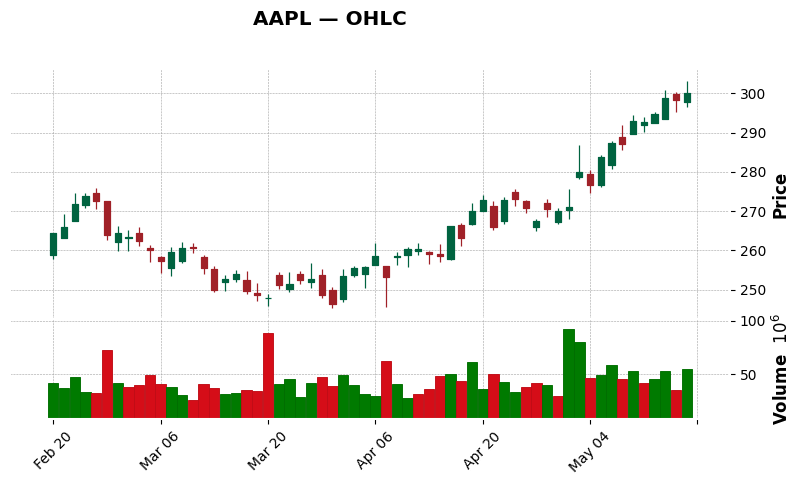

In [7]:
plot_stock_df(df, 'AAPL')

## Change the period

In [3]:
# Valid period values: '1d','5d','1mo','3mo','6mo','1y','2y','5y','max'
df_1y = get_stock_data('AAPL', period='1y')
print(f'1 year of data: {len(df_1y)} rows')
df_1y.head(3)

1 year of data: 251 rows


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-05-16 04:00:00,211.520861,211.730038,208.941099,210.425201,54737900,0.0,0.0
2025-05-19 04:00:00,207.088445,208.652233,203.452858,207.955002,46140500,0.0,0.0
2025-05-20 04:00:00,206.849384,207.646226,204.219817,206.042587,42496600,0.0,0.0


## Change the interval

In [4]:
# Valid interval values: '1m','5m','15m','30m','1h','1d','1wk','1mo'
# Note: intraday intervals only go back 60 days max
df_hourly = get_stock_data('AAPL', period='5d', interval='1h')
print(f'5 days of hourly bars: {len(df_hourly)} rows')
df_hourly.tail(5)

5 days of hourly bars: 35 rows


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-05-15 15:30:00,301.989990,302.600006,300.640015,301.809998,4948994,0.0,0.0
2026-05-15 16:30:00,301.790009,303.200012,301.484985,303.119995,4106966,0.0,0.0
2026-05-15 17:30:00,302.970001,303.140015,301.118011,301.265015,4178682,0.0,0.0
2026-05-15 18:30:00,301.279999,301.760010,299.880005,300.263397,4233250,0.0,0.0
2026-05-15 19:30:00,300.279999,300.660004,299.630005,300.220001,4618896,0.0,0.0


## Test error handling — bad ticker

In [5]:
result = get_stock_data('FAKEXYZ')
print(result)  # should print a warning and return None

[data] FAKEXYZ: fetch failed — HTTP Error 404: 
None


## Try your own ticker

In [6]:
ticker = 'NVDA'   # change this to whatever you want
period = '60d'    # change period
interval = '1d'   # change interval

df = get_stock_data(ticker, period=period, interval=interval)
if df is not None:
    print(f'{ticker}: {len(df)} rows')
    display(df[['Open', 'High', 'Low', 'Close', 'Volume']].tail(10))
    plot_stock_df(df, ticker)

NVDA: 60 rows


In [9]:
df.head

<bound method NDFrame.head of                            Open        High         Low       Close  \
Date                                                                  
2026-02-20 05:00:00  186.559914  190.319705  185.929943  189.809738   
2026-02-23 05:00:00  191.389641  193.939506  189.569748  191.539642   
2026-02-24 05:00:00  191.479642  193.759517  187.389852  192.839569   
2026-02-25 05:00:00  194.439467  197.619303  193.779500  195.549408   
2026-02-26 05:00:00  194.259487  194.279475  184.310028  184.879990   
2026-02-27 05:00:00  181.240198  182.580122  176.370466  177.180420   
2026-03-02 05:00:00  175.000526  183.450081  174.630551  182.470123   
2026-03-03 05:00:00  178.480340  180.890198  176.910417  180.040253   
2026-03-04 05:00:00  180.430240  184.690004  180.050256  183.030090   
2026-03-05 05:00:00  181.160197  184.050040  177.870382  183.330078   
2026-03-06 05:00:00  179.830259  182.750099  176.810433  177.810379   
2026-03-09 04:00:00  176.820429  182.900102  17